## 4.1 Evaluation metrics: session overview

- I used https://www.kaggle.com/blastchar/telco-customer-churn
- Metric - function that compares the predictions with the actual values and outputs a single number that tells how good the predictions are

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer

%matplotlib inline

In [2]:
df = pd.read_csv('Teleco-customer-churn.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [3]:
df_full_train, df_test = train_test_split(df, train_size=.60, test_size=.40, random_state=42)
df_val, df_test = train_test_split(df_test, train_size=.5, test_size=0.5, random_state=42)

df_train = df_full_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [4]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
 
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [5]:
dv = DictVectorizer(sparse=False)

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

model = LogisticRegression(C=0.01, max_iter=10000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

In [6]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.fit_transform(val_dicts)

y_predict = model.predict_proba(X_val)[:, 1]

churn_threshold = (y_predict >= 0.5)
(churn_threshold == y_val).mean()

np.float64(0.8161816891412349)

In [7]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1


## 4.2 Accuracy and Dummy model

- Evaluate the model on different thresholds
- Check the accuracy of dummy baseline
- Class Imbalance problem

In [8]:
len(y_val)

1409

In [9]:
(y_val == churn_threshold).sum()

np.int64(1150)

In [10]:
_ / len(y_val)

np.float64(0.8161816891412349)

0.00 0.268
0.05 0.473
0.10 0.568
0.15 0.649
0.20 0.707
0.25 0.749
0.30 0.773
0.35 0.787
0.40 0.801
0.45 0.815
0.50 0.816
0.55 0.811
0.60 0.799
0.65 0.784
0.70 0.762
0.75 0.740
0.80 0.732
0.85 0.732
0.90 0.732
0.95 0.732
1.00 0.732


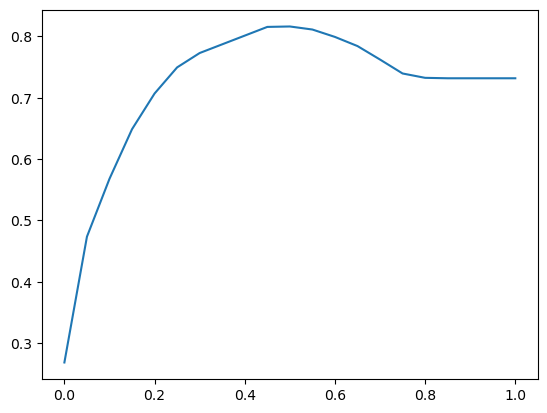

In [11]:
thresholds = np.linspace(0, 1, 21)
scores = []

for t in thresholds:
    churn_threshold = (y_predict >= t)
    score = (y_val == churn_threshold).mean()
    print('%.2f %.3f' % (t, score))
    scores.append(score)

plt.plot(thresholds, scores)
plt.show()

In [12]:
from sklearn.metrics import accuracy_score

In [13]:
thresholds = np.linspace(0, 1, 21)
scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_predict >= t) 
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.268
0.05 0.473
0.10 0.568
0.15 0.649
0.20 0.707
0.25 0.749
0.30 0.773
0.35 0.787
0.40 0.801
0.45 0.815
0.50 0.816
0.55 0.811
0.60 0.799
0.65 0.784
0.70 0.762
0.75 0.740
0.80 0.732
0.85 0.732
0.90 0.732
0.95 0.732
1.00 0.732


- Interpreting First and Last thresholds.

<img src='evaluation1.png' width='50%'>
- This mean when threshold is 1, every customer is not churn, because no values are higher or equal than 1

In [14]:
from collections import Counter

In [15]:
(y_predict >= 1.0).sum()

np.int64(0)

In [16]:
Counter(y_predict >= 1.0) # so there's no one  (every customer not churning)

Counter({np.False_: 1409})

- So here is the problem of accuracy; it does Not tell us how good the model is for this particular case, and this is happend because the distribution of (y) is imbalanced.
<img src='evaluation2.png' width='50%'>

In [17]:
# most of them are not churn
print(Counter(y_val))

print(y_val.mean()) # churn
print(1 - y_val.mean()) # not churn

Counter({np.int64(0): 1031, np.int64(1): 378})
0.26827537260468415
0.7317246273953159


- They are not correct when customer is churning

<img src='evaluation3.png' width='50%'>

## 4.3 Confusion table

- Different types of errors and correct decisions
- Arranging them in a table

<img src='evaluation4.png' width='50%'>

<img src='evaluation5.png' width='50%'>

<img src='evaluation6.png' width='50%'>

In [18]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [19]:
t = 0.5
predict_postive = (y_predict >= t)
predict_negative = (y_predict < t)

In [20]:
tp = (predict_postive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_postive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

<img src='evaluation7.png' width='50%'>

In [21]:
confusion_matrix = np.array([
    
    [tn, fp],
    [fn, tp]
])

confusion_matrix

array([[940,  91],
       [168, 210]])

In [22]:
# normalize it

((confusion_matrix / confusion_matrix.sum()).round(2))

# accuracy = (total tures) / (total tures & falses)

array([[0.67, 0.06],
       [0.12, 0.15]])

## 4.4 Precision and Recall1

In [23]:
# Accuracy
(tp + tn) / (tp + tn + fp + fn)

np.float64(0.8161816891412349)

##### Precision

<img src='evaluation8.png' width='50%'>

<img src='evaluation9.png' width='50%'>

In [24]:
# precision

precision = (tp) / (tp + fp)
precision

# this mean we will send promotiaonl email to (tp + fp) (31%) 300 customers, 209 of them are actually going to churn 

np.float64(0.6976744186046512)

##### Recall

<img src='evaluation10.png' width='50%'>

<img src='evaluation11.png' width='50%'>

<img src='evaluation12.png' width='50%'>

In [25]:
recall = tp / (tp + fn)
recall

np.float64(0.5555555555555556)

##### Understand them all:

<img src='evaluation13.png' width='50%'>

- even if the accuracy is 80%, but when look at recall we see the model is not good, so conclude the accuracy is not the best metric


<img src='evaluation14.png' width='50%'>

<img src='evaluation15.png' width='50%'>

## 4.5 ROC Curves

- stands for receiver operating characteristics, and this is a way of describing the performance of a binary classification model

#### TPR and FPR

<img src='evaluation16.png' width='50%'>

In [26]:
# all examples are actually positive (same as Recall)
tpr = tp / (tp + fn)

# FPR: is the fraction of false positives amont all positives examples
# all examples are actually negative
fpr = fp / (fp + tn)

print(tpr)
print(fpr)

0.5555555555555556
0.08826382153249272


In [27]:
# ROC curve looks at all the possible thresholds
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_postive = (y_predict >= t)
    predict_negative = (y_predict < t)
    
    tp = (predict_postive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_postive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, tn, fn))

In [28]:
scores

[(np.float64(0.0), np.int64(378), np.int64(1031), np.int64(0), np.int64(0)),
 (np.float64(0.01), np.int64(377), np.int64(960), np.int64(71), np.int64(1)),
 (np.float64(0.02), np.int64(377), np.int64(886), np.int64(145), np.int64(1)),
 (np.float64(0.03), np.int64(375), np.int64(829), np.int64(202), np.int64(3)),
 (np.float64(0.04), np.int64(375), np.int64(781), np.int64(250), np.int64(3)),
 (np.float64(0.05), np.int64(375), np.int64(739), np.int64(292), np.int64(3)),
 (np.float64(0.06), np.int64(374), np.int64(707), np.int64(324), np.int64(4)),
 (np.float64(0.07), np.int64(373), np.int64(680), np.int64(351), np.int64(5)),
 (np.float64(0.08), np.int64(371), np.int64(654), np.int64(377), np.int64(7)),
 (np.float64(0.09), np.int64(369), np.int64(629), np.int64(402), np.int64(9)),
 (np.float64(0.1), np.int64(367), np.int64(598), np.int64(433), np.int64(11)),
 (np.float64(0.11), np.int64(365), np.int64(566), np.int64(465), np.int64(13)),
 (np.float64(0.12), np.int64(364), np.int64(537), np.i

In [29]:
columns = ['thrshold', 'tp', 'fp', 'tn', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.tn + df_scores.fp)

df_scores

,thrshold,tp,fp,tn,fn,tpr,fpr
0,0.00,378,1031,0,0,1.000000,1.000000
1,0.01,377,960,71,1,0.997354,0.931135
2,0.02,377,886,145,1,0.997354,0.859360
3,0.03,375,829,202,3,0.992063,0.804074
4,0.04,375,781,250,3,0.992063,0.757517
...,...,...,...,...,...,...,...
96,0.96,0,0,1031,378,0.000000,0.000000
97,0.97,0,0,1031,378,0.000000,0.000000
98,0.98,0,0,1031,378,0.000000,0.000000
99,0.99,0,0,1031,378,0.000000,0.000000


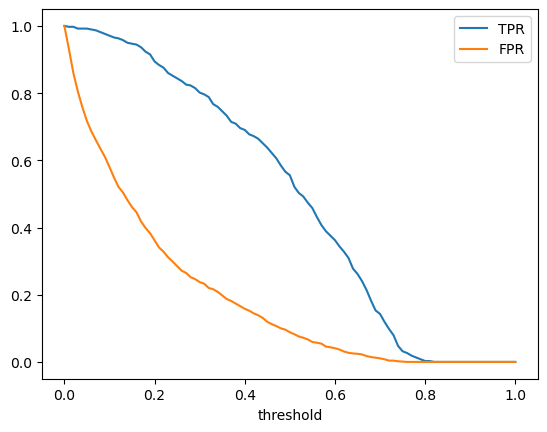

In [30]:
plt.plot(df_scores.thrshold, df_scores.tpr, label='TPR')
plt.plot(df_scores.thrshold, df_scores.fpr, label='FPR')

plt.xlabel('threshold')

plt.legend()
plt.show()

- this plot does Not give enough insights, because there is nothing to compare it with. 
<img src='evaluation17.png' width='50%'>

In [31]:
np.random.seed(42)
y_rand = np.random.uniform(0, 1, size=len(y_val))
y_rand.round(3)

array([0.375, 0.951, 0.732, ..., 0.844, 0.806, 0.585], shape=(1409,))

In [32]:
# the accuracy
((y_rand >= 0.5) == y_val).mean()

np.float64(0.49538679914833217)

In [33]:
scores = []
thresholds = np.linspace(0, 1, 101)

def tpr_fpr_score(y_val, y_predict):
    
    for t in thresholds:
        
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        
        predict_postive = (y_predict >= t)
        predict_negative = (y_predict < t)
        
        tp = (predict_postive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        
        fp = (predict_postive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
    
        scores.append((t, tp, fp, tn, fn))
    
        
    columns = ['thrshold', 'tp', 'fp', 'tn', 'fn']
    df_score = pd.DataFrame(scores, columns=columns)
    
    df_score['tpr'] = df_score.tp / (df_score.tp + df_score.fn)
    df_score['fpr'] = df_score.fp / (df_score.tn + df_score.fp)

    return df_score

In [34]:
df_rand = tpr_fpr_score(y_val, y_rand)
df_rand[::10]

,thrshold,tp,fp,tn,fn,tpr,fpr
0,0.0,378,1031,0,0,1.000000,1.000000
10,0.1,340,918,113,38,0.899471,0.890398
20,0.2,295,808,223,83,0.780423,0.783705
30,0.3,256,710,321,122,0.677249,0.688652
40,0.4,224,609,422,154,0.592593,0.590689
50,0.5,189,522,509,189,0.500000,0.506305
60,0.6,162,409,622,216,0.428571,0.396702
70,0.7,120,304,727,258,0.317460,0.294859
80,0.8,80,211,820,298,0.211640,0.204656
90,0.9,41,102,929,337,0.108466,0.098933


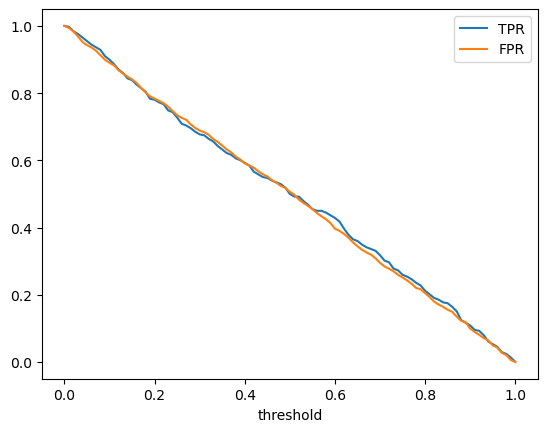

In [35]:
plt.plot(df_rand.thrshold, df_rand.tpr, label='TPR')
plt.plot(df_rand.thrshold, df_rand.fpr, label='FPR')

plt.xlabel('threshold')

plt.legend()
plt.show()